# Survival Comparison

Plots training curves of various methods using multiseed runs.

In [37]:
import os
import json
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ── Working directory: project root ───────────────────────────────────────────
if Path.cwd().name == "experiments":
    os.chdir("..")
ROOT = Path.cwd()

FIGURES = ROOT / "experiments" / "survival" / "obs_spaces"
FIGURES.mkdir(exist_ok=True, parents=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})

# ── Method registry ────────────────────────────────────────────────────────────
METHODS = {
    "Default": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/default/CustomPPO*/",
        "color": "tab:blue",
    },
    "Elements": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/elements/CustomPPO*/",
        "color": "tab:orange",
    },
    "Elements + LODF": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/elements_lodf/CustomPPO*/",
        "color": "tab:green",
    },
    "Heterogeneous": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/heterogenous/CustomPPO*/",
        "color": "tab:red",
    },
    "LODF": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/lodf/CustomPPO*/",
        "color": "tab:purple",
    },
    "MLP": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/mlp/CustomPPO*/",
        "color": "tab:brown",
    },
    "PTDF": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/ptdf/CustomPPO*/",
        "color": "tab:pink",
    },
    "Substation": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/substation/CustomPPO*/",
        "color": "tab:gray",
    },
    "Substation + PTDF": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/substation_ptdf/CustomPPO*/",
        "color": "tab:olive",
    },
    "Substation + Zbus": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/substation_zbus/CustomPPO*/",
        "color": "tab:cyan",
    },
    "Zbus": {
        "glob": "results/2026_08_17_compare_graph_obs_spaces_IEEE14/zbus/CustomPPO*/",
        "color": "gold",
    },
}

DO_NOTHING_PERFORMANCE = {
    "train": 1551.0,
    "test": 1949.3,
    "eval": 1812.7,
}

N_SEEDS     = 5
N_STEPS     = 100_000
SEED_LABELS = [f"Seed {i}" for i in range(N_SEEDS)]
STEP_GRID   = np.linspace(0, N_STEPS, 400)   # common x-axis for training curves

print(f"ROOT: {ROOT}")
print(f"Figures → {FIGURES}")


ROOT: /home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids
Figures → /home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/experiments/survival/obs_spaces


## Data Loading

**Training curves** are read from TensorBoard event files (`EventAccumulator`) and interpolated onto a shared 400-point step grid.
Two tags are loaded:
- `custom_metrics/grid2op_end_mean` — mean survival steps over the training batch
- `evaluation/custom_metrics/grid2op_end_mean` — mean survival steps over held-out evaluation episodes

**Survival arrays** come from `analysis/survival/survived_steps.npy` (144 values per seed).

In [38]:
TAG_TRAIN = "ray/tune/custom_metrics/grid2op_end_mean"
TAG_EVAL  = "ray/tune/evaluation/custom_metrics/grid2op_end_mean"


def load_tb_curve(trial_dir: Path, tag: str, x_grid: np.ndarray) -> np.ndarray:
    """Load a TensorBoard scalar and interpolate onto x_grid (linear, clamp edges)."""
    ea = EventAccumulator(str(trial_dir))
    ea.Reload()
    events = ea.Scalars(tag)
    steps  = np.array([e.step  for e in events], dtype=float)
    values = np.array([e.value for e in events], dtype=float)
    return np.interp(x_grid, steps, values)


def load_survival(trial_dir: Path) -> dict:
    """Load per-episode survival data for one seed.

    Returns a dict with:
      summary   – contents of summary.json
      steps     – raw survived steps per episode  (shape: [N])
      max_steps – episode max length per episode  (shape: [N])
      pct       – per-episode survival percentage (shape: [N]), 0–100
    """
    base = trial_dir / "analysis" / "survival"
    with (base / "summary.json").open() as f:
        summary = json.load(f)
    steps  = np.load(base / "survived_steps.npy")
    max_s  = np.load(base / "max_steps.npy")
    pct    = steps / np.maximum(max_s, 1) * 100
    return {"summary": summary, "steps": steps, "max_steps": max_s, "pct": pct}


# ── Load everything ────────────────────────────────────────────────────────────
curves   = {}   # method -> {"train": ndarray(N_SEEDS, 400), "eval": ...}
survival = {}   # method -> list[dict]  (length N_SEEDS)

for method, cfg in METHODS.items():
    dirs = sorted(ROOT.glob(cfg["glob"]))
    train_list, eval_list, surv_list = [], [], []
    for d in dirs:
        try:
            train_list.append(load_tb_curve(d, TAG_TRAIN, STEP_GRID))
            eval_list.append(load_tb_curve(d, TAG_EVAL,  STEP_GRID))
            surv_list.append(load_survival(d))
        except KeyError as e:
            print(f"method {method}: error reading data from {d}: \n{e}")

    train_arr = np.array(train_list) if train_list else np.empty((0, len(STEP_GRID)))
    eval_arr  = np.array(eval_list)  if eval_list  else np.empty((0, len(STEP_GRID)))
    assert train_arr.ndim == 2 and train_arr.shape[1] == len(STEP_GRID), (
        f"{method}: unexpected train shape {train_arr.shape} — "
        f"re-run setup cell (STEP_GRID) and data-loading cell in order"
    )
    assert eval_arr.ndim == 2 and eval_arr.shape[1] == len(STEP_GRID), (
        f"{method}: unexpected eval shape {eval_arr.shape} — "
        f"re-run setup cell (STEP_GRID) and data-loading cell in order"
    )
    curves[method]   = {"train": train_arr, "eval": eval_arr}
    survival[method] = surv_list
    ep_max = int(surv_list[0]["max_steps"].max()) if surv_list else "?"
    n_ok   = len(train_list)
    print(f"  {method}: {n_ok}/{len(dirs)} seeds loaded, max_episode_steps={ep_max}")

# Derive MAX_EP_STEPS from data (works across environments)
MAX_EP_STEPS = int(max(
    s["max_steps"].max()
    for method_data in survival.values()
    for s in method_data
))
print(f"\nMAX_EP_STEPS (from data): {MAX_EP_STEPS}")


  Default: 5/5 seeds loaded, max_episode_steps=8064
  Elements: 5/5 seeds loaded, max_episode_steps=8064
  Elements + LODF: 5/5 seeds loaded, max_episode_steps=8064
  Heterogeneous: 5/5 seeds loaded, max_episode_steps=8064
  LODF: 5/5 seeds loaded, max_episode_steps=8064
  MLP: 5/5 seeds loaded, max_episode_steps=8064
  PTDF: 5/5 seeds loaded, max_episode_steps=8064
  Substation: 5/5 seeds loaded, max_episode_steps=8064
  Substation + PTDF: 5/5 seeds loaded, max_episode_steps=8064
method Substation + Zbus: error reading data from /home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/results/2026_08_17_compare_graph_obs_spaces_IEEE14/substation_zbus/CustomPPO_GNN_5080057_5acac_2026-08-17_09-57-55: 
'Key ray/tune/custom_metrics/grid2op_end_mean was not found in Reservoir'
method Substation + Zbus: error reading data from /home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/results/2026_08_17_compare_graph_obs_spaces_IEEE14/substation_zbus/CustomPPO_GNN_5080067_db399_2026-08-17_10-44-2

## Training Curves

Shaded band = mean ± 1 std across 5 seeds. Dashed line marks the maximum episode length (8 062 steps = full survival).

**Batch mean** reflects the noisy online signal during training; **evaluation mean** is measured on held-out episodes at fixed checkpoints and is the more reliable indicator of policy quality.

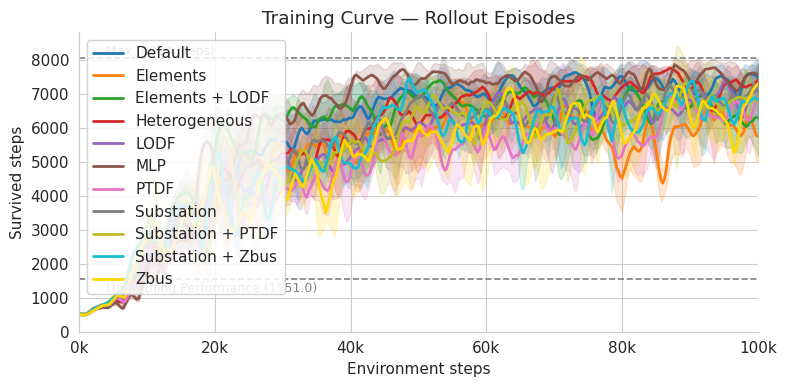

In [39]:
def plot_training_curve(
    tag_key: str,
    title: str,
    ylabel: str,
    filename: str,
    subset: list[str] | None = None,
    do_nothing_performance: Optional[float] = None
) -> None:
    """Plot mean ± std training curves.

    Args:
        tag_key:  'train' or 'eval'
        title:    plot title
        ylabel:   y-axis label
        filename: output filename under FIGURES/
        subset:   list of method names to include; None = all methods
        do_nothing_performance: performance of do nothing agent can be shown as horizontal line
    """
    methods = {k: v for k, v in METHODS.items() if subset is None or k in subset}
    fig, ax = plt.subplots(figsize=(8, 4))

    for method, cfg in methods.items():
        arr = curves[method][tag_key]   # (N_SEEDS, len(STEP_GRID))
        if arr.ndim != 2 or arr.shape[0] == 0 or arr.shape[1] != len(STEP_GRID):
            print(f"Warning: {method} has unexpected shape {arr.shape}, skipping — "
                  "re-run data-loading cell after the setup cell")
            continue
        mean = arr.mean(axis=0)
        std  = arr.std(axis=0)
        ax.plot(STEP_GRID, mean, label=method, color=cfg["color"], lw=2)
        ax.fill_between(STEP_GRID, mean - std, mean + std,
                        color=cfg["color"], alpha=0.18)

    ax.axhline(MAX_EP_STEPS, ls="--", color="gray", lw=1.2)
    ax.text(4_000, MAX_EP_STEPS + 80, f"Max ({MAX_EP_STEPS} steps)",
            color="gray", fontsize=9)
    if do_nothing_performance is not None:
        ax.axhline(do_nothing_performance, ls="--", color="gray", lw=1.2)
        ax.text(4_000, do_nothing_performance - 380, f"Do Nothing Performance ({do_nothing_performance})",
            color="gray", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Environment steps")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1_000)}k"))
    ax.set_xlim(0, N_STEPS)
    ax.set_ylim(bottom=0)
    ax.legend(framealpha=0.85)
    sns.despine(ax=ax)
    plt.tight_layout()
    fig.savefig(FIGURES / filename, dpi=150)
    plt.show()


plot_training_curve(
    "train",
    "Training Curve — Rollout Episodes",
    "Survived steps",
    "training_curve_batch.png",
    do_nothing_performance=DO_NOTHING_PERFORMANCE["train"]
)

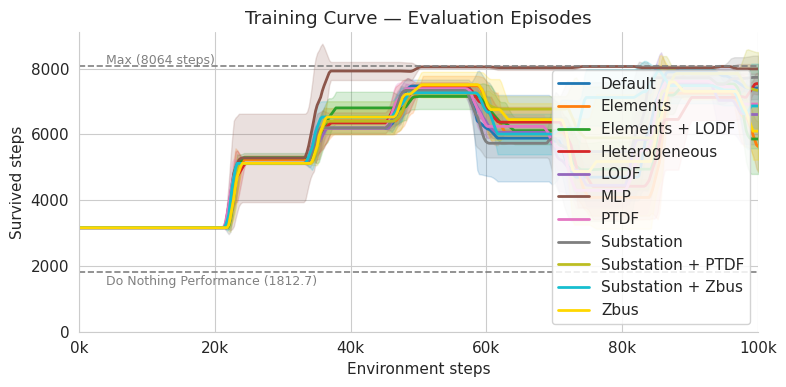

In [40]:
plot_training_curve(
    "eval",
    "Training Curve — Evaluation Episodes",
    "Survived steps",
    "training_curve_eval.png",
    do_nothing_performance=DO_NOTHING_PERFORMANCE["eval"]
)

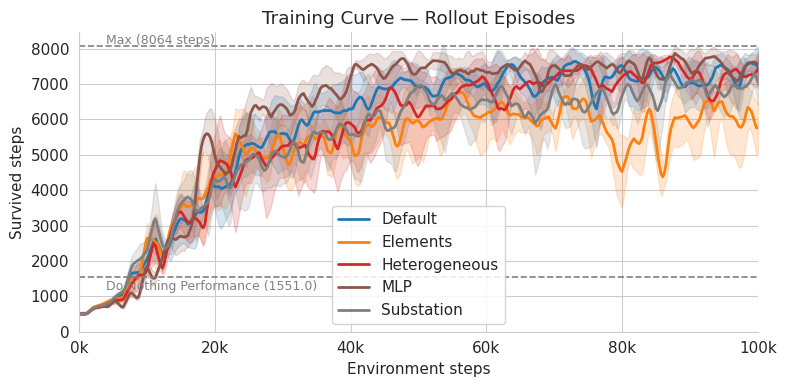

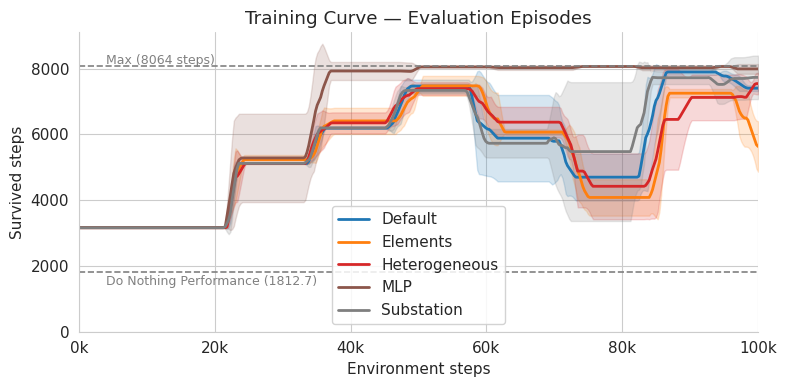

In [41]:
# Plot 2/3/4 subset: Baselines & Single-Feature Obs
_subset = ['MLP', 'Default', 'Elements', 'Heterogeneous', 'Substation']

plot_training_curve(
    "train",
    "Training Curve — Rollout Episodes",
    "Survived steps",
    "training_curve_topology.png",
    subset=_subset,
    do_nothing_performance=DO_NOTHING_PERFORMANCE["train"]
)
plot_training_curve(
    "eval",
    "Training Curve — Evaluation Episodes",
    "Survived steps",
    "training_curve_eval_topology.png",
    subset=_subset,
    do_nothing_performance=DO_NOTHING_PERFORMANCE["eval"]
)

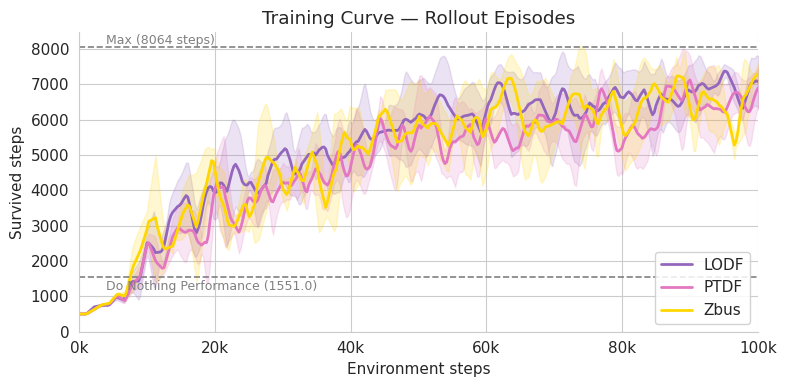

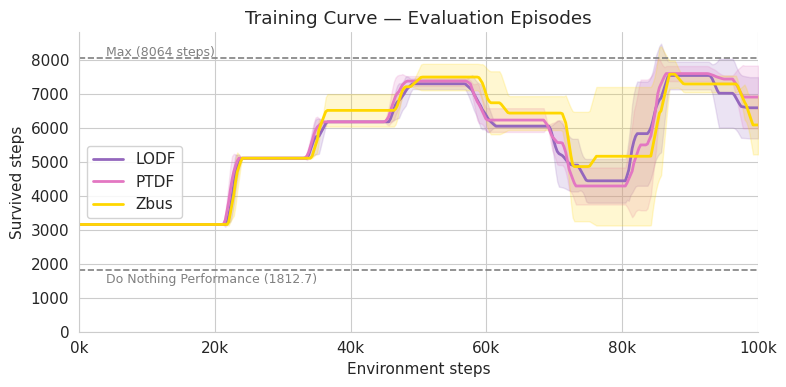

In [42]:
# Plot 2/3/4 subset: Power-Flow Features (PTDF / LODF / Zbus)
_subset = ['PTDF', 'LODF', 'Zbus']

plot_training_curve(
    "train",
    "Training Curve — Rollout Episodes",
    "Survived steps",
    "training_curve_power_flow.png",
    subset=_subset,
    do_nothing_performance=DO_NOTHING_PERFORMANCE["train"]
)
plot_training_curve(
    "eval",
    "Training Curve — Evaluation Episodes",
    "Survived steps",
    "training_curve_eval_power_flow.png",
    subset=_subset,
    do_nothing_performance=DO_NOTHING_PERFORMANCE["eval"]
)

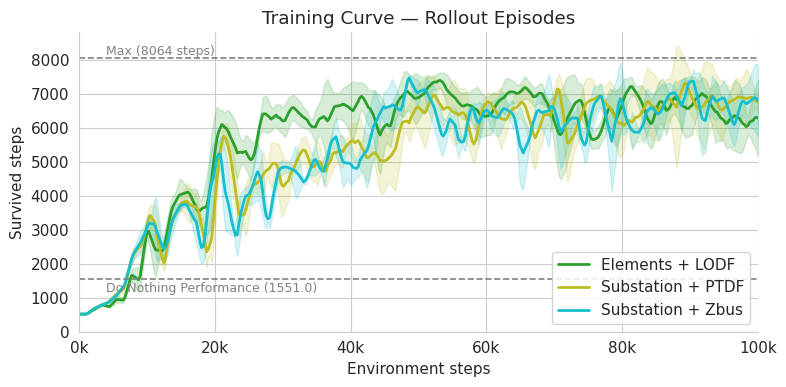

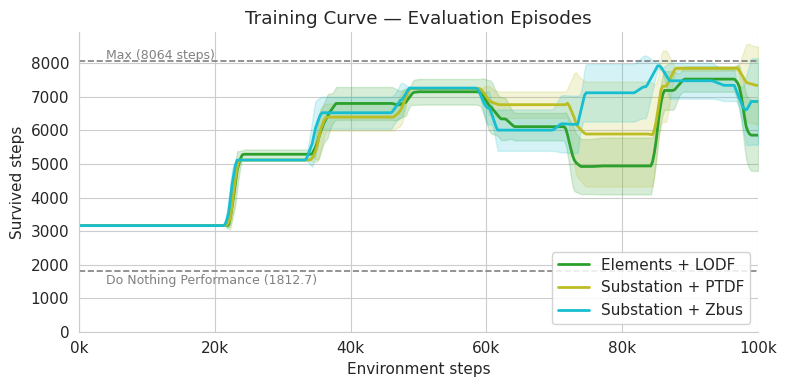

In [43]:
# Plot 2/3/4 subset: Combined Obs Spaces
_subset = ['Elements + LODF', 'Substation + PTDF', 'Substation + Zbus']

plot_training_curve(
    "train",
    "Training Curve — Rollout Episodes",
    "Survived steps",
    "training_curve_rollout_combined.png",
    subset=_subset,
    do_nothing_performance=DO_NOTHING_PERFORMANCE["train"]
)
plot_training_curve(
    "eval",
    "Training Curve — Evaluation Episodes",
    "Survived steps",
    "training_curve_eval_combined.png",
    subset=_subset,
    do_nothing_performance=DO_NOTHING_PERFORMANCE["eval"]
)

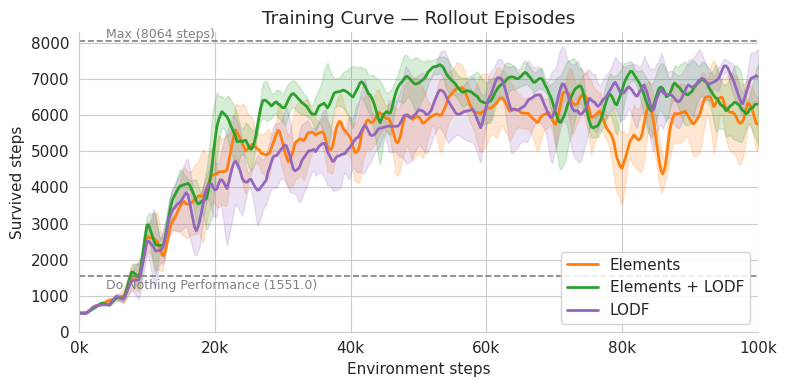

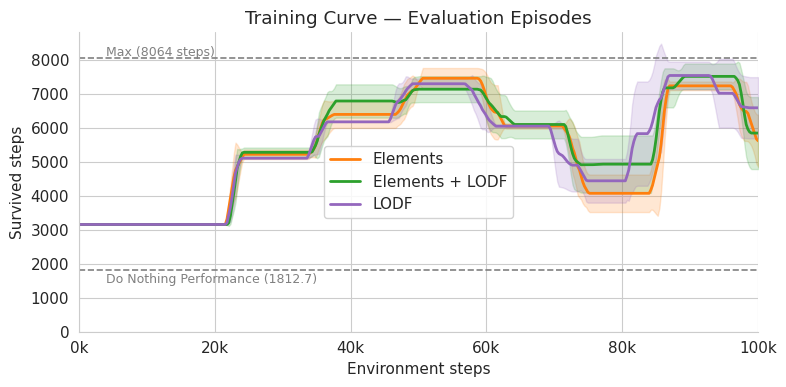

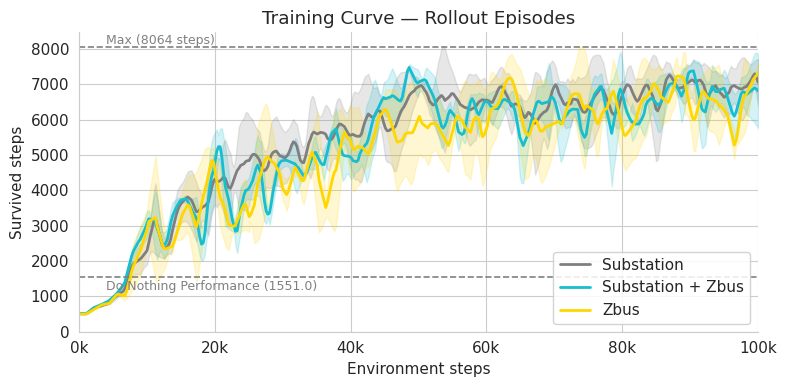

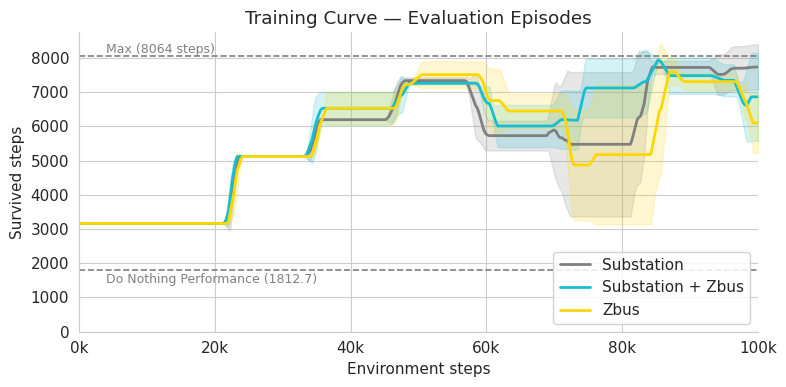

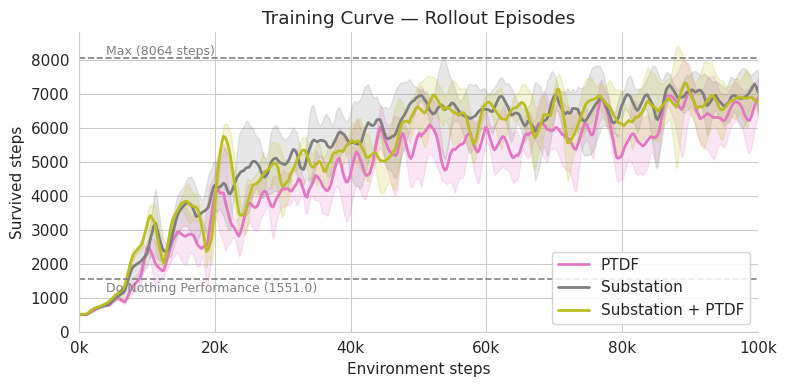

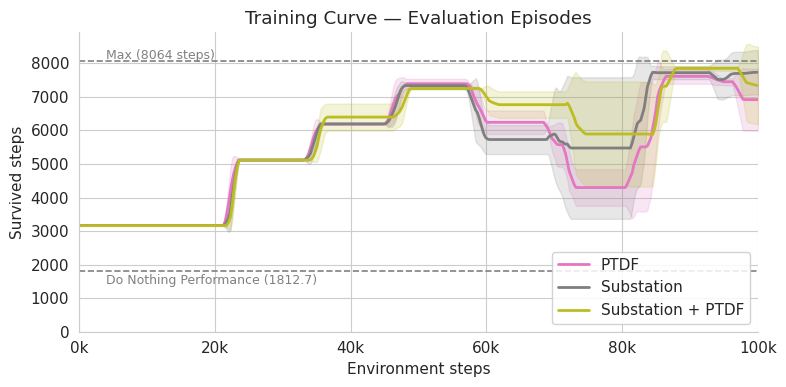

In [44]:
# compare combined vs individual
_subsets = [
    ['Elements', 'LODF', 'Elements + LODF'],
    ['Substation', 'Zbus', 'Substation + Zbus'],
    ['Substation', 'PTDF', 'Substation + PTDF']
]
for _subset in _subsets:
    plot_training_curve(
        "train",
        "Training Curve — Rollout Episodes",
        "Survived steps",
        f"training_curve_rollout_{_subset[0].lower()}_{_subset[1].lower()}.png",
        subset=_subset,
        do_nothing_performance=DO_NOTHING_PERFORMANCE["train"]
    )
    plot_training_curve(
        "eval",
        "Training Curve — Evaluation Episodes",
        "Survived steps",
        f"training_curve_eval_{_subset[0].lower()}_{_subset[1].lower()}.png",
        subset=_subset,
        do_nothing_performance=DO_NOTHING_PERFORMANCE["eval"]
)

## Test Survival — Boxplots

Survival duration measured on held-out test episodes per seed, using the **best checkpoint** of each run.

- **Y-axis: survival %** — `survived_steps / max_steps × 100` per episode, normalised with that episode's own max so the axis is always 0–100 regardless of environment.
- A value of 100 % means the agent survived the full episode.
- Dots show individual episode outcomes (strip overlay). For high-performing models most dots cluster near 100 %; the few failing episodes appear as isolated dots below — look carefully for them.


Default: 202/210 episodes at 100 % survival
Elements: 182/210 episodes at 100 % survival
Elements + LODF: 194/210 episodes at 100 % survival
Heterogeneous: 196/210 episodes at 100 % survival
LODF: 199/210 episodes at 100 % survival
MLP: 195/210 episodes at 100 % survival
PTDF: 189/210 episodes at 100 % survival
Substation: 203/210 episodes at 100 % survival
Substation + PTDF: 196/210 episodes at 100 % survival
Substation + Zbus: 120/126 episodes at 100 % survival
Zbus: 111/126 episodes at 100 % survival


/tmp/ipykernel_16511/779121310.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


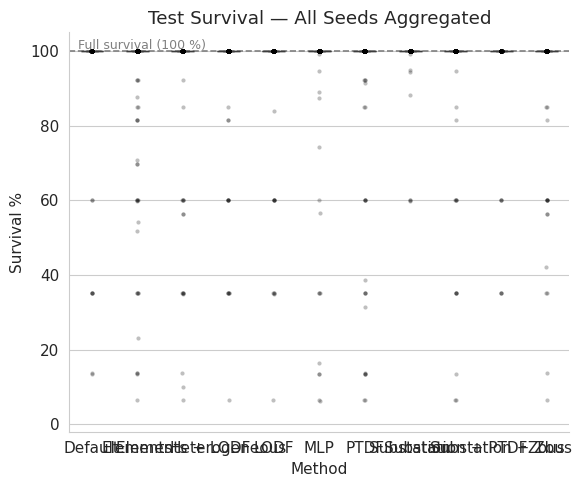

In [45]:
# ── Build dataframe: one row per episode ───────────────────────────────────────
records = []
for method in METHODS:
    for s in survival[method]:
        for pct_val in s["pct"]:
            records.append({"Method": method, "Survival %": float(pct_val)})

df_agg = pd.DataFrame(records)

# ── Diagnostic: print how many episodes hit 100 % per method ──────────────────
for method in METHODS:
    total = sum(len(s["pct"]) for s in survival[method])
    perfect = sum((s["pct"] == 100).sum() for s in survival[method])
    print(f"{method}: {perfect}/{total} episodes at 100 % survival")

# ── Plot ───────────────────────────────────────────────────────────────────────
palette = {m: cfg["color"] for m, cfg in METHODS.items()}

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=df_agg, x="Method", y="Survival %",
    palette=palette, width=0.5, fliersize=0, ax=ax,
)
# Larger, more opaque dots so outlier episodes stand out even when few
sns.stripplot(
    data=df_agg, x="Method", y="Survival %",
    color="black", alpha=0.25, size=3.0, jitter=0.01, ax=ax,
)
ax.axhline(100, ls="--", color="gray", lw=1.2)
ax.text(2.52, 100.5, "Full survival (100 %)", color="gray", fontsize=9, ha="right")
ax.set_ylim(-2, 105)
ax.set_title("Test Survival — All Seeds Aggregated")
ax.set_ylabel("Survival %")
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES / "boxplot_aggregated.png", dpi=150)
plt.show()


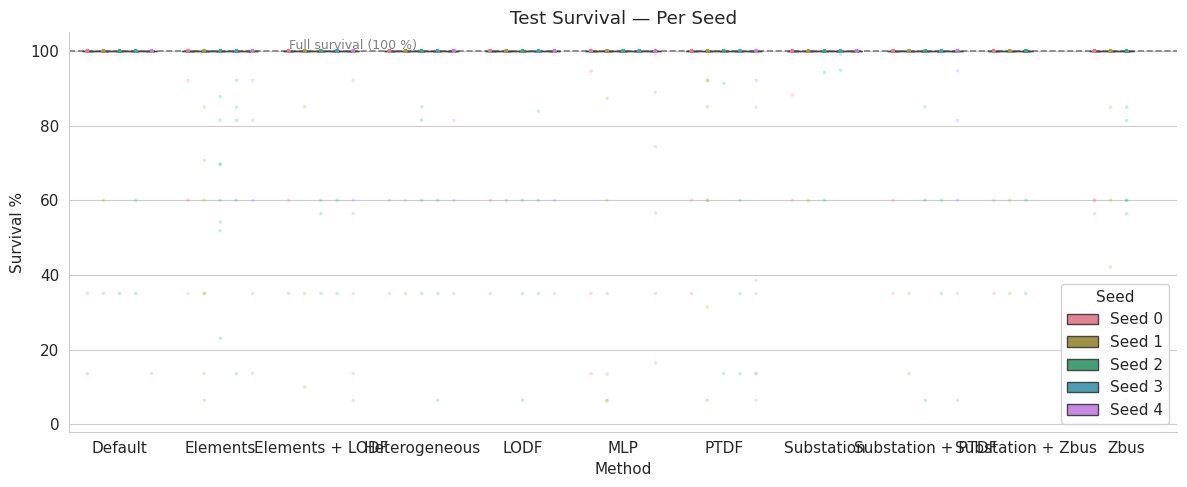

In [46]:
# ── Build dataframe: one row per episode, with seed label ──────────────────────
records_seed = []
for method in METHODS:
    for i, s in enumerate(survival[method]):
        for pct_val in s["pct"]:
            records_seed.append({
                "Method": method,
                "Seed": SEED_LABELS[i],
                "Survival %": float(pct_val),
            })

df_seed = pd.DataFrame(records_seed)
seed_palette  = dict(zip(SEED_LABELS, sns.color_palette("husl", N_SEEDS)))
method_order  = list(METHODS.keys())

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_seed, x="Method", y="Survival %", hue="Seed",
    palette=seed_palette, width=0.75, fliersize=0,
    order=method_order, ax=ax,
)
sns.stripplot(
    data=df_seed, x="Method", y="Survival %", hue="Seed",
    palette=seed_palette, dodge=True, alpha=0.25, size=2.5,
    jitter=0.01, legend=False, order=method_order, ax=ax,
)
ax.axhline(100, ls="--", color="gray", lw=1.2)
ax.text(2.95, 100.5, "Full survival (100 %)", color="gray", fontsize=9, ha="right")
ax.set_ylim(-2, 105)
ax.set_title("Test Survival — Per Seed")
ax.set_ylabel("Survival %")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:N_SEEDS], labels[:N_SEEDS], title="Seed",
          loc="lower right", framealpha=0.85)
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES / "boxplot_per_seed.png", dpi=150)
plt.show()


## Summary Tables

Metrics derived from `analysis/survival/summary.json` per seed:

- **Surv. Episodes %** — fraction of the 144 test episodes where the agent survived until the end (`grid2op_end == max_steps`).
- **Surv. Steps %** — mean survived steps across all episodes, expressed as a percentage of the max episode length (8 062 steps). This accounts for partial survival in failed episodes.
- **Steps μ** — mean survived steps (absolute) averaged over episodes within a seed. In the aggregate table the `±` is std across seeds (between-seed variability).
- **Steps σ within** — std of survived steps over episodes within a seed (within-seed episode spread). In the aggregate table the `±` is std across seeds (consistency of this spread).


In [47]:
# ── Aggregate table: one row per method, averaged across seeds ─────────────────
from tabulate import tabulate

rows = []
for method in METHODS:
    ep_pcts  = [s["summary"]["completed_episodes_pct"] for s in survival[method]]
    st_pcts  = [s["summary"]["survived_steps_pct"]     for s in survival[method]]
    st_means = [s["summary"]["survived_steps_mean"]    for s in survival[method]]
    st_stds  = [s["summary"]["survived_steps_std"]     for s in survival[method]]
    rows.append([
        method,
        np.mean(ep_pcts),                               # sort key (col 1)
        f"{np.mean(ep_pcts):.1f} ± {np.std(ep_pcts):.1f}",
        f"{np.mean(st_pcts):.1f} ± {np.std(st_pcts):.1f}",
        f"{np.mean(st_means):.0f} ± {np.std(st_means):.0f}",
        f"{np.mean(st_stds):.0f} ± {np.std(st_stds):.0f}",
    ])

rows.sort(key=lambda r: r[1], reverse=True)
rows = [[r[0], r[2], r[3], r[4], r[5]] for r in rows]   # drop sort key

headers = ["Method", "Surv. Episodes %", "Surv. Steps %", "Steps μ (± seed σ)", "Steps σ within (± seed σ)"]
print("Aggregate (mean ± std across seeds, sorted by Surv. Episodes %)\n")
print(tabulate(rows, headers=headers, tablefmt="github"))


Aggregate (mean ± std across seeds, sorted by Surv. Episodes %)

| Method            | Surv. Episodes %   | Surv. Steps %   | Steps μ (± seed σ)   | Steps σ within (± seed σ)   |
|-------------------|--------------------|-----------------|----------------------|-----------------------------|
| Substation        | 96.7 ± 1.9         | 99.3 ± 0.5      | 8009 ± 41            | 312 ± 230                   |
| Default           | 96.2 ± 1.2         | 97.6 ± 0.7      | 7867 ± 55            | 1006 ± 175                  |
| Substation + Zbus | 95.2 ± 0.0         | 97.5 ± 0.0      | 7863 ± 0             | 927 ± 0                     |
| LODF              | 94.8 ± 1.8         | 97.3 ± 1.2      | 7845 ± 97            | 948 ± 305                   |
| Heterogeneous     | 93.3 ± 1.8         | 96.8 ± 0.8      | 7807 ± 66            | 1043 ± 205                  |
| Substation + PTDF | 93.3 ± 2.8         | 96.5 ± 1.0      | 7783 ± 83            | 1175 ± 214                  |
| MLP               | 9

In [48]:
# ── Per-method tables: one row per seed + summary row ─────────────────────────
from tabulate import tabulate

for method in METHODS:
    rows = []
    ep_pcts, st_pcts, st_means, st_stds = [], [], [], []

    for i, s in enumerate(survival[method]):
        sm = s["summary"]
        rows.append([
            SEED_LABELS[i],
            f"{sm['completed_episodes_pct']:.1f}",
            f"{sm['survived_steps_pct']:.1f}",
            f"{sm['survived_steps_mean']:.0f}",
            f"{sm['survived_steps_std']:.0f}",
        ])
        ep_pcts.append(sm["completed_episodes_pct"])
        st_pcts.append(sm["survived_steps_pct"])
        st_means.append(sm["survived_steps_mean"])
        st_stds.append(sm["survived_steps_std"])

    rows.append([
        "Mean ± Std",
        f"{np.mean(ep_pcts):.1f} ± {np.std(ep_pcts):.1f}",
        f"{np.mean(st_pcts):.1f} ± {np.std(st_pcts):.1f}",
        f"{np.mean(st_means):.0f} ± {np.std(st_means):.0f}",
        f"{np.mean(st_stds):.0f} ± {np.std(st_stds):.0f}",
    ])

    headers = ["Seed", "Surv. Episodes %", "Surv. Steps %", "Steps μ", "Steps σ within"]
    print(f"\n{'─'*60}")
    print(f"  {method}")
    print(f"{'─'*60}")
    print(tabulate(rows, headers=headers, tablefmt="rounded_outline"))
    print()



────────────────────────────────────────────────────────────
  Default
────────────────────────────────────────────────────────────
╭────────────┬────────────────────┬─────────────────┬───────────┬──────────────────╮
│ Seed       │ Surv. Episodes %   │ Surv. Steps %   │ Steps μ   │ Steps σ within   │
├────────────┼────────────────────┼─────────────────┼───────────┼──────────────────┤
│ Seed 0     │ 95.2               │ 96.4            │ 7773      │ 1314             │
│ Seed 1     │ 95.2               │ 97.5            │ 7862      │ 928              │
│ Seed 2     │ 97.6               │ 98.5            │ 7939      │ 799              │
│ Seed 3     │ 95.2               │ 97.5            │ 7862      │ 928              │
│ Seed 4     │ 97.6               │ 97.9            │ 7898      │ 1062             │
│ Mean ± Std │ 96.2 ± 1.2         │ 97.6 ± 0.7      │ 7867 ± 55 │ 1006 ± 175       │
╰────────────┴────────────────────┴─────────────────┴───────────┴──────────────────╯


───────────────